In [109]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

In [110]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=30,
)

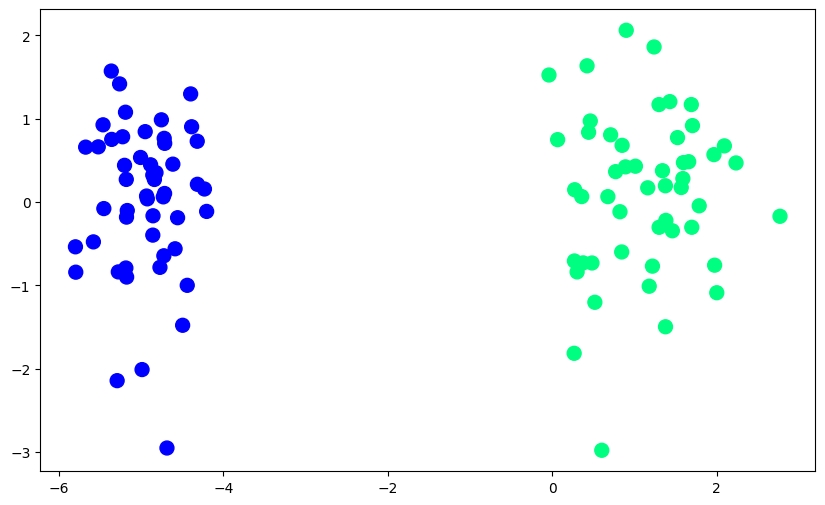

In [111]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="winter", s=100)

#### Applying `sklearn.LogisticRegression`

In [112]:
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression(penalty=None, solver="sag")
lor.fit(X, y)

print(lor.intercept_, "\n", lor.coef_)

[4.24504176] 
 [[3.81669852 0.16302018]]


/home/slayer0x10/dev/ml/ml-study/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [113]:
m1 = -(lor.coef_[0][0] / lor.coef_[0][1])
b1 = -(lor.intercept_ / lor.coef_[0][1])

In [114]:
x_input = np.linspace(-3, 3, 100)
y_input = m1 * x_input + b1

---
### Own `LogisticRegression` with GradientDescent

In [115]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [129]:
def gd(X: np.ndarray, y: np.ndarray, epochs: int = 1000, learing_rate: float = 0.5):

    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = learing_rate

    for _ in range(epochs):
        y_hat = sigmoid(np.dot(X, weights))

        weights = weights + (lr) * (np.dot((y - y_hat), X) / X.shape[0])

    return weights[0], weights[1:]

In [130]:
intercept_, coef_ = gd(X, y, epochs=3000)
print(intercept_, "\n", coef_)

4.669050984110743 
 [3.29738965 0.12297964]


In [131]:
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [132]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m * x_input1 + b

(-3.0, 2.0)

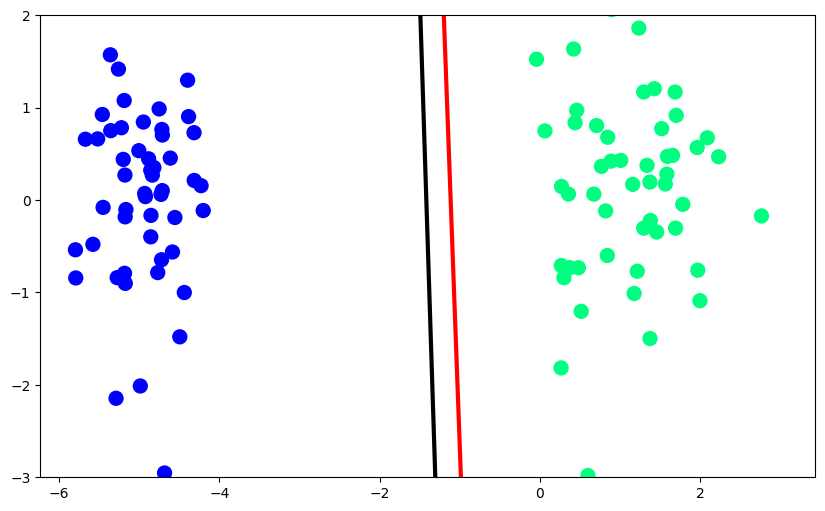

In [133]:
plt.figure(figsize=(10, 6))
plt.plot(x_input, y_input, color="red", linewidth=3)  # linear regresison
plt.plot(x_input1, y_input1, color="black", linewidth=3)  # gradient descent
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="winter", s=100)
plt.ylim(-3, 2)